# 1. Problem statement
### This project is to understand how the student's performance is affected by varialbles such as Gender, ethincity, parent level of education, lunch, test preperation course

# 2. Data Collection
- Data source: https://www.kaggle.com/datasets/spscientist/students-performance-in-exams

# Import data and require pakage

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')


In [2]:
data = pd.read_csv('data\StudentsPerformance.xls')
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


# 3. Dataset Overview
### 3.1 Check shape and column names

In [3]:
print(data.shape)
print(data.columns)

(1000, 8)
Index(['gender', 'race/ethnicity', 'parental level of education', 'lunch',
       'test preparation course', 'math score', 'reading score',
       'writing score'],
      dtype='object')


### 3.2 Data types and null values


In [4]:
print(data.info())
print("null value in each columns is :")
print(data.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 8 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   gender                       1000 non-null   object
 1   race/ethnicity               1000 non-null   object
 2   parental level of education  1000 non-null   object
 3   lunch                        1000 non-null   object
 4   test preparation course      1000 non-null   object
 5   math score                   1000 non-null   int64 
 6   reading score                1000 non-null   int64 
 7   writing score                1000 non-null   int64 
dtypes: int64(3), object(5)
memory usage: 62.6+ KB
None
null value in each columns is :
gender                         0
race/ethnicity                 0
parental level of education    0
lunch                          0
test preparation course        0
math score                     0
reading score                  0
writin

### 3.3 Number of unique values in each columns

In [5]:
print(data.nunique())

gender                          2
race/ethnicity                  5
parental level of education     6
lunch                           2
test preparation course         2
math score                     81
reading score                  72
writing score                  77
dtype: int64


### 3.4 Summary statistics (for numerical columns)

In [6]:
data.describe()

,math score,reading score,writing score
count,1000.00000,1000.000000,1000.000000
mean,66.08900,69.169000,68.054000
std,15.16308,14.600192,15.195657
min,0.00000,17.000000,10.000000
25%,57.00000,59.000000,57.750000
50%,66.00000,70.000000,69.000000
75%,77.00000,79.000000,79.000000
max,100.00000,100.000000,100.000000


#### Insight from .describe() of Scores: 
- The mean scores for math, reading, and writing are all close to each other, around the mid-60s to low 70s range. Specifically:
- Math: Mean ≈ 66
- Reading: Mean ≈ 69
- Writing: Mean ≈ 68
       
   - #### The standard deviations for all three subjects are also very similar (≈ 14–15), suggesting that student performance has a consistent spread across subjects. There are no extreme outliers skewing one subject more than others.

   - #### This uniformity may indicate that most students perform similarly across all subjects, and no subject is dramatically harder or easier in terms of scoring.

### 3.5 Explorign data

#### categorical columns

In [7]:
for col in data.columns:
    if data[col].dtype == 'O':
        print(data[col].value_counts())
        print(" ")


gender
female    518
male      482
Name: count, dtype: int64
 
race/ethnicity
group C    319
group D    262
group B    190
group E    140
group A     89
Name: count, dtype: int64
 
parental level of education
some college          226
associate's degree    222
high school           196
some high school      179
bachelor's degree     118
master's degree        59
Name: count, dtype: int64
 
lunch
standard        645
free/reduced    355
Name: count, dtype: int64
 
test preparation course
none         642
completed    358
Name: count, dtype: int64
 


#### Numerical Columns — Value Counts

In [8]:
print(data['math score'].describe())
print(data['reading score'].describe())
print(data['writing score'].describe())



count    1000.00000
mean       66.08900
std        15.16308
min         0.00000
25%        57.00000
50%        66.00000
75%        77.00000
max       100.00000
Name: math score, dtype: float64
count    1000.000000
mean       69.169000
std        14.600192
min        17.000000
25%        59.000000
50%        70.000000
75%        79.000000
max       100.000000
Name: reading score, dtype: float64
count    1000.000000
mean       68.054000
std        15.195657
min        10.000000
25%        57.750000
50%        69.000000
75%        79.000000
max       100.000000
Name: writing score, dtype: float64


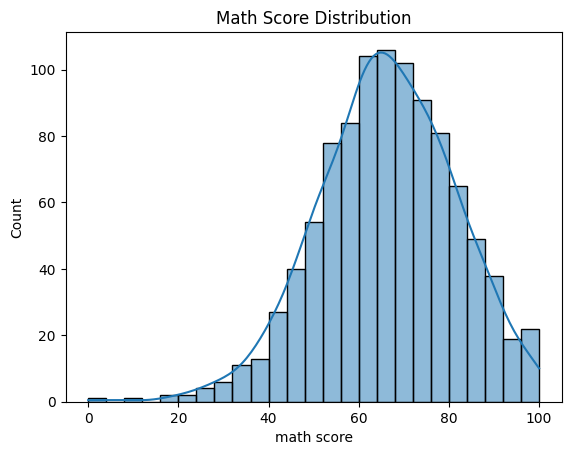

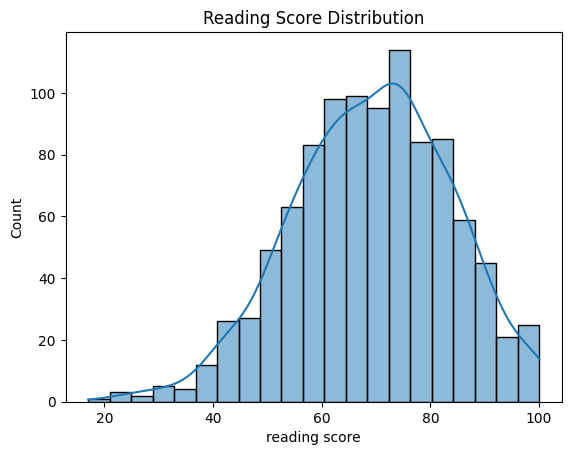

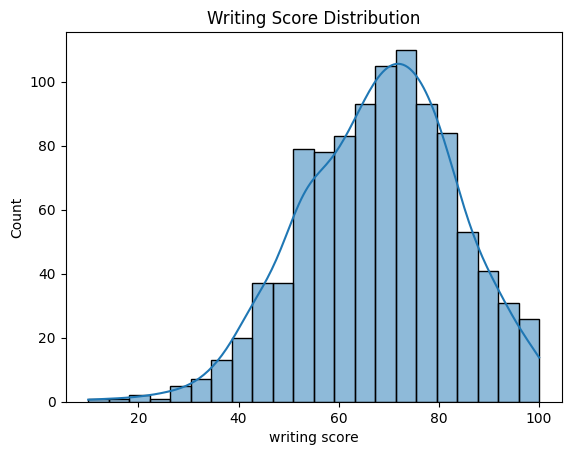

In [9]:
sns.histplot(data['math score'], kde=True)
plt.title("Math Score Distribution")
plt.show()

sns.histplot(data['reading score'], kde=True)
plt.title("Reading Score Distribution")
plt.show()

sns.histplot(data['writing score'], kde=True)
plt.title("Writing Score Distribution")
plt.show()


## 3.6 Adding columns for "Total Score" and "Average"

In [10]:
data['Total Score'] = data['math score'] + data['reading score'] + data['writing score']
data['Average'] = data['Total Score']/3
data.head()

,gender,race/ethnicity,parental level of education,lunch,test preparation course,math score,reading score,writing score,Total Score,Average
0,female,group B,bachelor's degree,standard,none,72,72,74,218,72.666667
1,female,group C,some college,standard,completed,69,90,88,247,82.333333
2,female,group B,master's degree,standard,none,90,95,93,278,92.666667
3,male,group A,associate's degree,free/reduced,none,47,57,44,148,49.333333
4,male,group C,some college,standard,none,76,78,75,229,76.333333


# 4. Exploring data (visualisation)

### 4.1 Distribution Plots for Numerical Columns

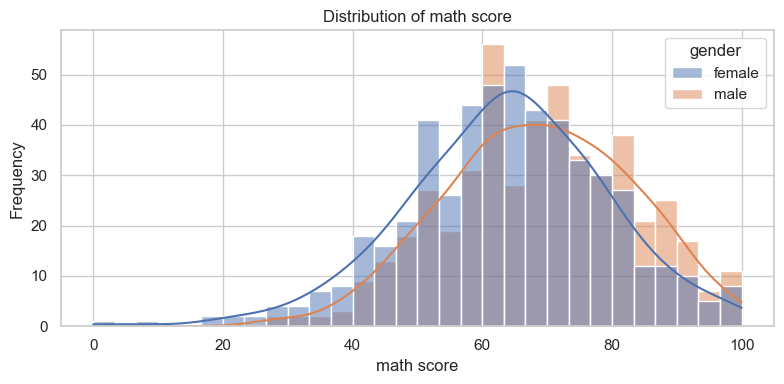

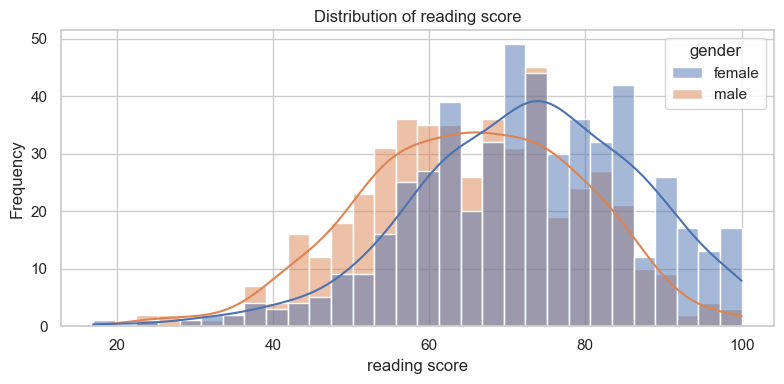

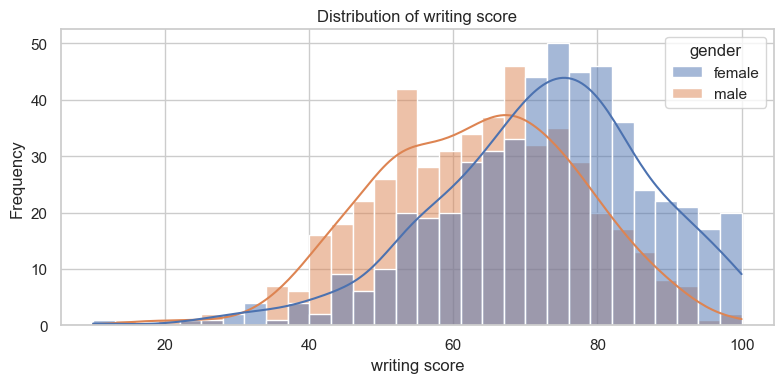

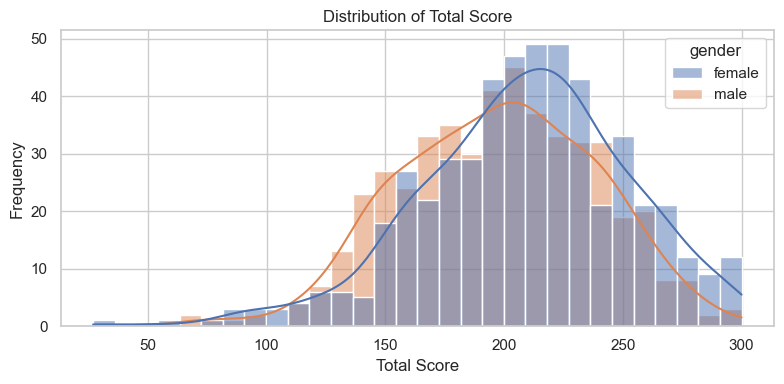

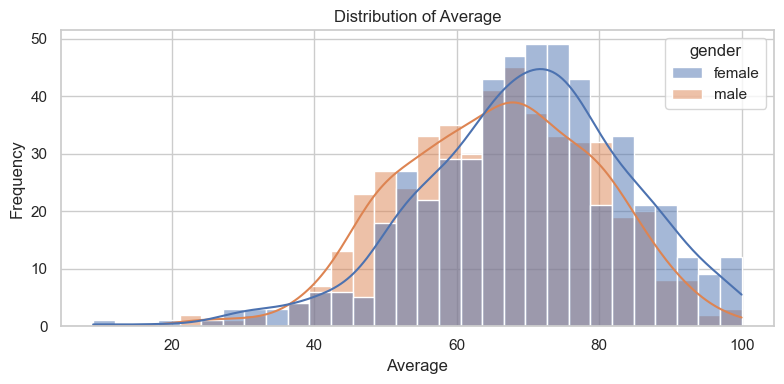

In [11]:
# Set a common style
sns.set(style="whitegrid")

# Plot distributions one by one
columns = ['math score', 'reading score', 'writing score', 'Total Score', 'Average']

for col in columns:
    plt.figure(figsize=(8, 4))
    sns.histplot(data = data, x = col, kde=True, bins=30, color='skyblue', hue=data['gender'])
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
    plt.tight_layout()
    plt.show()


#### Distribution Insights (with Gender Comparison):
- Overall Shape:
    All three distributions — math, reading, and writing — appear to be right-skewed, meaning more students scored in the higher range, and fewer performed poorly.

- Math Score:
The distribution shows that male students tend to perform slightly better in math. Their curve has a higher frequency in the upper score range (above 70), while female scores are more centered around the mean.

- Reading & Writing Scores:
In both reading and writing, female students dominate the higher score ranges. The KDE curve for females is taller and shifts slightly right compared to males, suggesting better overall performance in language subjects.

- Average and Total Score:
You might also notice that females have a slightly tighter and higher distribution in average scores, possibly due to consistent performance across reading and writing.

### 4.2  Insights from Categorical Feature Visualizations:

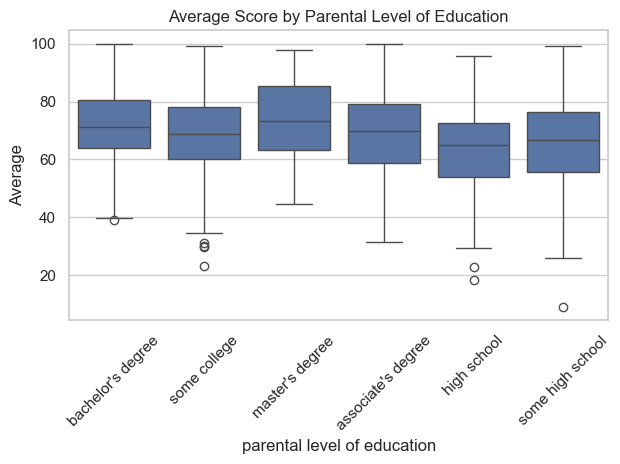

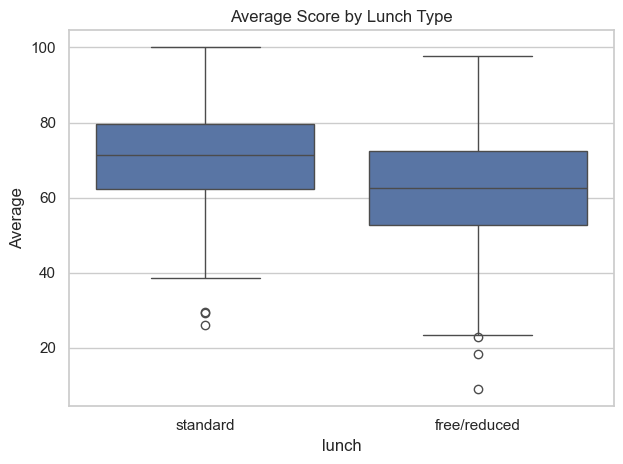

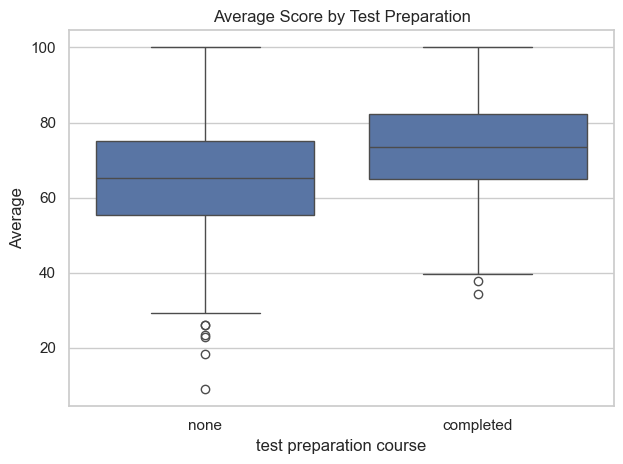

In [17]:
sns.boxplot(data=data, x='parental level of education', y='Average')
plt.xticks(rotation=45)
plt.title("Average Score by Parental Level of Education")
plt.tight_layout()
plt.show()

# Lunch type
sns.boxplot(data=data, x='lunch', y='Average')
plt.title("Average Score by Lunch Type")
plt.tight_layout()
plt.show()

# Test preparation course
sns.boxplot(data=data, x='test preparation course', y='Average')
plt.title("Average Score by Test Preparation")
plt.tight_layout()
plt.show()


- ####  Parental Level of Education:
    - Despite expectations, there is no strong or consistent impact of parental education level on students' average scores. Students whose parents have master’s or bachelor’s degrees do not significantly outperform those whose parents have only high school or associate degrees.
    - This may suggest that external factors like resources, school support, or self-motivation play a stronger role than parental education.

- #### Lunch Type:
    - Students who receive standard lunch consistently score higher in all subjects compared to those on free/reduced lunch.
    - This difference likely reflects socioeconomic status, with better-nourished students having an academic advantage.

- #### Test Preparation Course:
   - Students who completed a test preparation course perform significantly better than those who didn’t.
   - This suggests that preparation courses are effective and positively impact academic performance across all subjects.

 ### 4.3 Most common score range

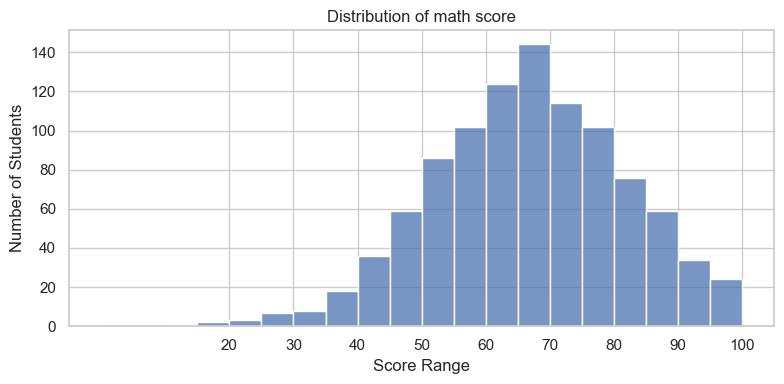

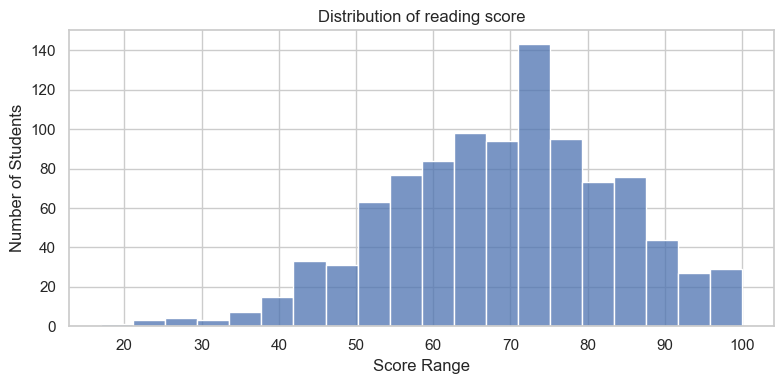

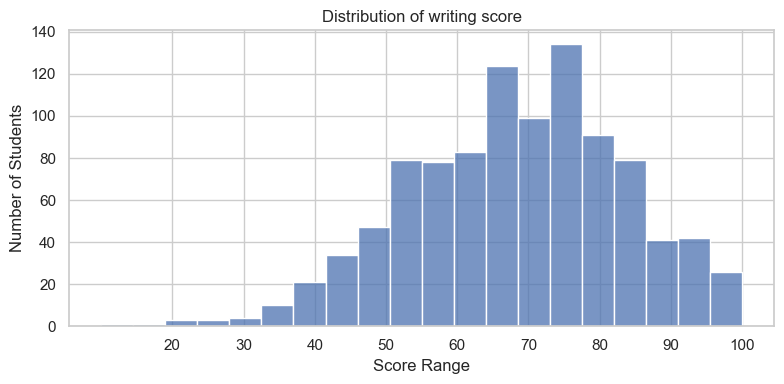

In [21]:
for col in ['math score', 'reading score', 'writing score']:
    plt.figure(figsize=(8, 4))
    sns.histplot(data=data, x=col, bins=20)
    plt.title(f'Distribution of {col}')
    plt.xlabel('Score Range')
    plt.ylabel('Number of Students')
    plt.xticks(range(20, 110, 10))
    plt.tight_layout()
    plt.show()





## Insights
#### - From the above bar graph it is clear that most of the students score in between 60-80 in maths and 50-85 in reading and writing

# 5. Bivariate Aanlyis
- This involves exploring relationships between variables 
                                — especially numeric ones

## Goal
- Understand how different features are related to each other. For example:
    - Do students who score high in math also do well in reading/writing?
    - Are some subjects more correlated than others?
    - Is there a linear pattern?